# 09 - Optimization Layer

Takes the best model (LGBM walk-forward) and builds a probability-based
strike selection strategy. Compares naive argmax with probability-weighted
and risk-adjusted approaches.

**Strategies**:
1. Argmax -- pick the class with highest predicted probability
2. Probability-weighted -- weight by expected return per bucket
3. Risk-adjusted -- factor in volatility regime and prediction confidence

**Output**: `strike_recommendations.csv` for backtesting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from lightgbm import LGBMClassifier

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
FIGURES = Path('../reports/figures')
SEED = 42
np.random.seed(SEED)

UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']
label_names = {0: 'ATM', 1: 'OTM5', 2: 'OTM10'}
label_list = ['ATM', 'OTM5', 'OTM10']

## 1. Load Data and Add IV Features

In [2]:
data = pd.read_parquet(PROCESSED / 'daily_modeling_data.parquet')
data['date'] = pd.to_datetime(data['date'])

# Add IV features (same pipeline as 06c)
options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
calls = options[(options['call_put'] == 'CALL') & (options['symbol'].isin(UNIVERSE))].copy()
calls['trade_date'] = pd.to_datetime(calls['trade_date'])

atm = calls[(calls['delta'] >= 0.35) & (calls['delta'] <= 0.65)].copy()
daily_iv = atm.groupby(['symbol', 'trade_date']).agg(
    iv_mean=('implied_vol', 'mean'),
    iv_std=('implied_vol', 'std'),
).reset_index()

data = data.merge(daily_iv, left_on=['symbol', 'date'],
                  right_on=['symbol', 'trade_date'], how='left')
data = data.drop(columns=['trade_date'], errors='ignore')
data = data.sort_values(['symbol', 'date'])
data['iv_mean'] = data.groupby('symbol')['iv_mean'].transform(lambda x: x.ffill())
data['iv_std'] = data.groupby('symbol')['iv_std'].transform(lambda x: x.ffill())
data['iv_rank'] = data.groupby('symbol')['iv_mean'].transform(
    lambda x: x.rolling(252, min_periods=60).apply(
        lambda w: (w.iloc[-1] - w.min()) / (w.max() - w.min()) if w.max() != w.min() else 0.5))
data['iv_change'] = data.groupby('symbol')['iv_mean'].pct_change(21)

exclude = ['symbol', 'date', 'year_month', 'best_moneyness', 'best_return', 'label_3', 'year']
feature_cols = [c for c in data.columns if c not in exclude]
data[feature_cols] = data.groupby('symbol')[feature_cols].transform(lambda x: x.ffill())
data[feature_cols] = data[feature_cols].fillna(0)
data['year'] = data['date'].dt.year

print(f"Data shape: {data.shape}, Features: {len(feature_cols)}")
print(f"Date range: {data['date'].min().date()} to {data['date'].max().date()}")

Data shape: (29273, 38), Features: 31
Date range: 2008-02-01 to 2025-12-31


## 2. Walk-Forward Probability Predictions

Re-run the LGBM walk-forward loop but collect `predict_proba` outputs, not just
class predictions. This gives us the confidence distribution over ATM/OTM5/OTM10
for each test sample.

In [3]:
test_years = [y for y in sorted(data['year'].unique()) if y >= 2014]

rows = []

for test_year in test_years:
    tr = data[data['year'] < test_year]
    te = data[data['year'] == test_year]
    if len(tr) < 500:
        continue

    X_tr, y_tr = tr[feature_cols], tr['label_3']
    X_te, y_te = te[feature_cols], te['label_3']

    cw = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_tr)
    model = LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        num_leaves=50, subsample=0.8, colsample_bytree=0.7,
        min_child_samples=20, class_weight=dict(enumerate(cw)),
        random_state=SEED, verbose=-1, n_jobs=-1)
    model.fit(X_tr, y_tr)

    probs = model.predict_proba(X_te)
    preds = model.predict(X_te)

    fold_df = te[['symbol', 'date', 'label_3', 'best_moneyness',
                   'year_month', 'iv_rank', 'high_vol_regime', 'vol_21d']].copy()
    fold_df['prob_atm'] = probs[:, 0]
    fold_df['prob_otm5'] = probs[:, 1]
    fold_df['prob_otm10'] = probs[:, 2]
    fold_df['pred_argmax'] = preds
    rows.append(fold_df)

    acc = accuracy_score(y_te, preds)
    print(f"  {test_year}: test={len(te):,}, Acc={acc:.3f}")

predictions = pd.concat(rows, ignore_index=True)
predictions['confidence'] = predictions[['prob_atm', 'prob_otm5', 'prob_otm10']].max(axis=1)

print(f"\nTotal predictions: {len(predictions):,}")
print(f"Accuracy (argmax): {accuracy_score(predictions['label_3'], predictions['pred_argmax']):.4f}")
print(f"\nConfidence distribution:")
print(predictions['confidence'].describe().round(3))

  2014: test=1,770, Acc=0.340


  2015: test=2,023, Acc=0.672


  2016: test=2,055, Acc=0.791


  2017: test=2,037, Acc=0.779


  2018: test=1,878, Acc=0.806


...

  2021: test=2,097, Acc=0.732


  2022: test=2,386, Acc=0.669


  2023: test=2,300, Acc=0.469


  2024: test=2,110, Acc=0.435


  2025: test=2,090, Acc=0.532

Total predictions: 24,669
Accuracy (argmax): 0.6372

Confidence distribution:
count    24669.000
mean         0.875
std          0.161
min          0.340
25%          0.791
50%          0.959
75%          0.997
max          1.000
Name: confidence, dtype: float64


## 3. Compute Historical Average Returns per Bucket

Use the monthly labels data to compute the average covered call return for each
moneyness bucket. This serves as the expected return weight for the
probability-weighted strategy.

In [4]:
# Compute average returns per moneyness bucket from the options data
# Re-derive from the options payoff computation (same logic as notebook 05)
daily_prices = pd.read_parquet(PROCESSED / 'daily_clean.parquet')
daily_prices = daily_prices[daily_prices['symbol'].isin(UNIVERSE)].copy()
daily_prices['date'] = pd.to_datetime(daily_prices['date'])

calls_full = calls.copy()
calls_full['expiration'] = pd.to_datetime(calls_full['expiration'])

def assign_moneyness(delta):
    if 0.15 <= delta < 0.30:
        return 'OTM10'
    elif 0.30 <= delta < 0.45:
        return 'OTM5'
    elif 0.45 <= delta <= 0.60:
        return 'ATM'
    return None

calls_full['moneyness'] = calls_full['delta'].apply(assign_moneyness)
calls_valid = calls_full.dropna(subset=['moneyness']).copy()
calls_valid = calls_valid[(calls_valid['dte'] >= 7) & (calls_valid['dte'] <= 120)] if 'dte' in calls_valid.columns else calls_valid

# Compute DTE if not present
if 'dte' not in calls_valid.columns:
    calls_valid['dte'] = (calls_valid['expiration'] - calls_valid['trade_date']).dt.days
    calls_valid = calls_valid[(calls_valid['dte'] >= 7) & (calls_valid['dte'] <= 120)]

# Merge prices
prices = daily_prices[['symbol', 'date', 'adjusted_close']].rename(
    columns={'adjusted_close': 'price'})
calls_valid = calls_valid.merge(
    prices.rename(columns={'date': 'trade_date', 'price': 'entry_price'}),
    on=['symbol', 'trade_date'], how='left')

# Exit price via merge_asof
exit_prices = prices.rename(columns={'date': 'expiration', 'price': 'exit_price'})
result_list = []
for sym in UNIVERSE:
    left = calls_valid[calls_valid['symbol'] == sym].sort_values('expiration')
    right = exit_prices[exit_prices['symbol'] == sym].sort_values('expiration')
    merged = pd.merge_asof(left, right[['expiration', 'exit_price']],
                           on='expiration', direction='backward')
    result_list.append(merged)
calls_valid = pd.concat(result_list, ignore_index=True)

# Compute returns
calls_valid['premium'] = calls_valid['mark'].fillna(
    (calls_valid['bid'] + calls_valid['ask']) / 2)
calls_valid['stock_pnl'] = np.minimum(calls_valid['exit_price'], calls_valid['strike']) - calls_valid['entry_price']
calls_valid['total_pnl'] = calls_valid['premium'] + calls_valid['stock_pnl']
calls_valid['cc_return'] = calls_valid['total_pnl'] / calls_valid['entry_price']

# Filter outliers
calls_valid = calls_valid[
    (calls_valid['cc_return'] > -0.5) & (calls_valid['cc_return'] < 0.5) &
    (calls_valid['entry_price'] > 0) & (calls_valid['premium'] > 0)
].copy()

# Average return by moneyness bucket
avg_returns_by_bucket = calls_valid.groupby('moneyness')['cc_return'].mean()
print("Average covered call return by moneyness bucket:")
print(avg_returns_by_bucket.round(4))

# Store as ordered array: [ATM, OTM5, OTM10]
avg_returns = np.array([
    avg_returns_by_bucket.get('ATM', 0),
    avg_returns_by_bucket.get('OTM5', 0),
    avg_returns_by_bucket.get('OTM10', 0)
])
print(f"\nReturn weights: ATM={avg_returns[0]:.4f}, OTM5={avg_returns[1]:.4f}, OTM10={avg_returns[2]:.4f}")

Average covered call return by moneyness bucket:
moneyness
ATM      0.1721
OTM10    0.1391
OTM5     0.2035
Name: cc_return, dtype: float64

Return weights: ATM=0.1721, OTM5=0.2035, OTM10=0.1391


## 4. Strategy Definitions

In [5]:
def strategy_argmax(row):
    """Pick the class with highest predicted probability."""
    return int(row['pred_argmax'])


def strategy_prob_weighted(row, avg_ret):
    """Weight each bucket by predicted probability times average historical return."""
    scores = np.array([
        row['prob_atm'] * avg_ret[0],
        row['prob_otm5'] * avg_ret[1],
        row['prob_otm10'] * avg_ret[2],
    ])
    return int(np.argmax(scores))


def strategy_risk_adjusted(row, avg_ret):
    """
    Risk-adjusted selection:
    - In high-vol regimes or when IV rank is elevated, boost ATM preference
      (collect more premium when volatility is rich)
    - When prediction confidence is low, default toward ATM (conservative)
    - Otherwise, trust the probability-weighted signal
    """
    probs = np.array([row['prob_atm'], row['prob_otm5'], row['prob_otm10']])
    confidence = probs.max()

    # Adjust probabilities based on regime
    adj = probs.copy()

    # High vol regime or high IV rank: favor ATM (higher premium capture)
    iv_rank = row.get('iv_rank', 0)
    high_vol = row.get('high_vol_regime', 0)
    if pd.notna(iv_rank) and iv_rank > 0.7:
        adj[0] *= 1.3
    if high_vol == 1:
        adj[0] *= 1.2

    # Low confidence: tilt toward ATM (safer choice)
    if confidence < 0.45:
        adj[0] *= 1.25

    # Compute risk-adjusted scores
    scores = adj * avg_ret
    return int(np.argmax(scores))


print("Strategies defined: argmax, prob_weighted, risk_adjusted")

Strategies defined: argmax, prob_weighted, risk_adjusted


## 5. Apply Strategies

In [6]:
# Apply each strategy
predictions['sel_argmax'] = predictions.apply(strategy_argmax, axis=1)
predictions['sel_prob_weighted'] = predictions.apply(
    lambda row: strategy_prob_weighted(row, avg_returns), axis=1)
predictions['sel_risk_adjusted'] = predictions.apply(
    lambda row: strategy_risk_adjusted(row, avg_returns), axis=1)

# Map numeric labels to names for readability
for col in ['sel_argmax', 'sel_prob_weighted', 'sel_risk_adjusted']:
    predictions[col + '_name'] = predictions[col].map(label_names)

# Accuracy of each strategy vs true label
strategies = {
    'Argmax': 'sel_argmax',
    'Prob-Weighted': 'sel_prob_weighted',
    'Risk-Adjusted': 'sel_risk_adjusted',
}

print("Strategy Accuracy vs True Best Moneyness:")
for name, col in strategies.items():
    acc = accuracy_score(predictions['label_3'], predictions[col])
    f1 = f1_score(predictions['label_3'], predictions[col], average='macro')
    print(f"  {name:20s}: Acc={acc:.4f}, F1={f1:.4f}")

# Distribution of selections per strategy
print("\nSelection Distribution:")
for name, col in strategies.items():
    dist = predictions[col].value_counts().sort_index()
    total = len(predictions)
    print(f"  {name}:")
    for label_id, count in dist.items():
        print(f"    {label_names[label_id]}: {count:,} ({count/total*100:.1f}%)")

Strategy Accuracy vs True Best Moneyness:
  Argmax              : Acc=0.6372, F1=0.4682
  Prob-Weighted       : Acc=0.6337, F1=0.4665
  Risk-Adjusted       : Acc=0.6397, F1=0.4666

Selection Distribution:
  Argmax:
    ATM: 17,230 (69.8%)
    OTM5: 3,024 (12.3%)
    OTM10: 4,415 (17.9%)
  Prob-Weighted:
    ATM: 17,253 (69.9%)
    OTM5: 3,361 (13.6%)
    OTM10: 4,055 (16.4%)
  Risk-Adjusted:
    ATM: 17,573 (71.2%)
    OTM5: 3,152 (12.8%)
    OTM10: 3,944 (16.0%)


## 6. Per-Year Strategy Comparison

Per-Year Accuracy by Strategy:
 year    n  Argmax  Prob-Weighted  Risk-Adjusted
 2014 1770  0.3401         0.3328         0.3356
 2015 2023  0.6718         0.6708         0.6752
 2016 2055  0.7908         0.7971         0.8005
 2017 2037  0.7791         0.7786         0.7865
 2018 1878  0.8056         0.8056         0.8062
 2019 1878  0.8062         0.8030         0.8104
 2020 2045  0.6244         0.6244         0.6333
 2021 2097  0.7325         0.7239         0.7358
 2022 2386  0.6693         0.6672         0.6878
 2023 2300  0.4691         0.4665         0.4700
 2024 2110  0.4346         0.4251         0.4227
 2025 2090  0.5321         0.5187         0.5191


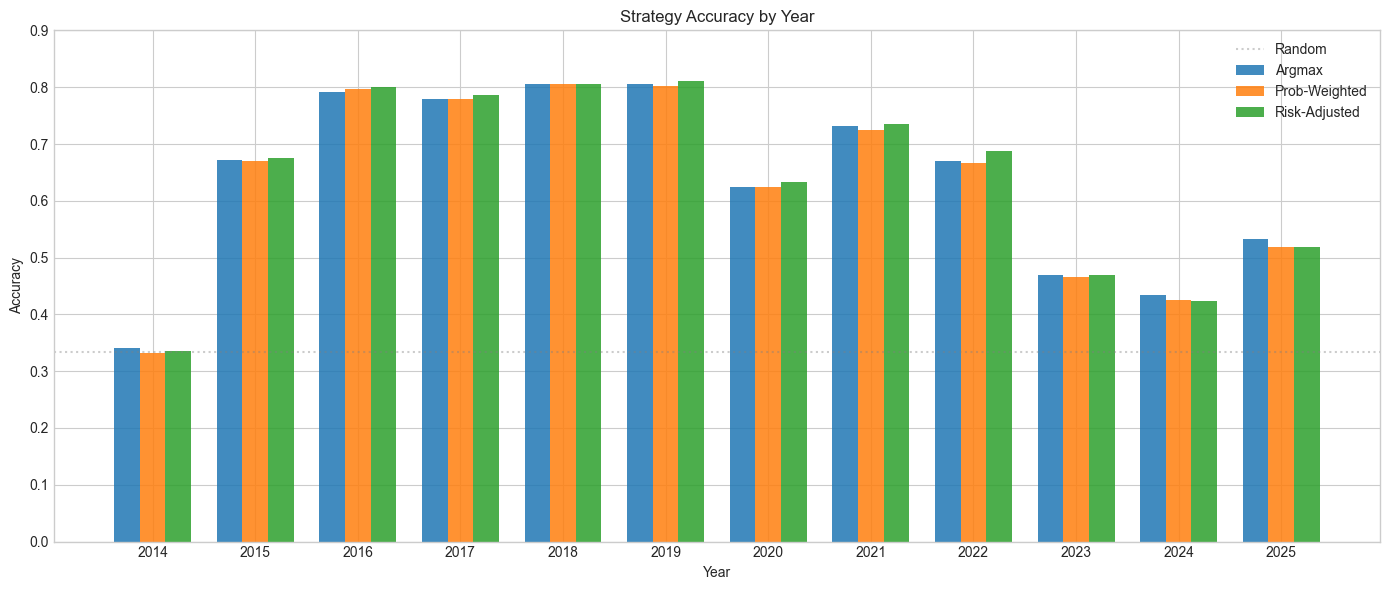

In [7]:
predictions['year'] = predictions['date'].dt.year

yearly_acc = []
for year in sorted(predictions['year'].unique()):
    subset = predictions[predictions['year'] == year]
    row = {'year': year, 'n': len(subset)}
    for name, col in strategies.items():
        row[name] = accuracy_score(subset['label_3'], subset[col])
    yearly_acc.append(row)

yearly_df = pd.DataFrame(yearly_acc)
print("Per-Year Accuracy by Strategy:")
print(yearly_df.round(4).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(yearly_df))
w = 0.25
for i, (name, _) in enumerate(strategies.items()):
    ax.bar(x + i * w, yearly_df[name], w, label=name, alpha=0.85)
ax.axhline(y=1/3, color='gray', linestyle=':', alpha=0.4, label='Random')
ax.set_xticks(x + w)
ax.set_xticklabels(yearly_df['year'].values)
ax.set_xlabel('Year')
ax.set_ylabel('Accuracy')
ax.set_title('Strategy Accuracy by Year')
ax.legend()
ax.set_ylim(0, 0.9)
plt.tight_layout()
plt.savefig(FIGURES / 'strategy_accuracy_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Portfolio Diversification

Apply a portfolio-level constraint: on any given day, cap any single moneyness
bucket at 60% of tickers. When exceeded, reassign excess positions to the
next-best bucket by probability score.

In [8]:
def apply_diversification(group, max_pct=0.6, base_col='sel_risk_adjusted'):
    """
    For a single day's group of tickers, enforce that no bucket exceeds
    max_pct of the portfolio. Reassign overflow positions to their
    second-best bucket.
    """
    group = group.copy()
    group['sel_diversified'] = group[base_col].values.copy()

    n_tickers = len(group)
    max_per_bucket = int(np.ceil(n_tickers * max_pct))

    prob_cols = ['prob_atm', 'prob_otm5', 'prob_otm10']

    for _ in range(3):  # iterate to resolve cascading overflow
        counts = group['sel_diversified'].value_counts()
        overflow_buckets = counts[counts > max_per_bucket].index.tolist()
        if not overflow_buckets:
            break

        for bucket in overflow_buckets:
            mask = group['sel_diversified'] == bucket
            bucket_rows = group[mask].copy()
            n_excess = len(bucket_rows) - max_per_bucket

            if n_excess <= 0:
                continue

            # Sort by probability of this bucket (ascending) -- reassign the
            # least-confident ones first
            bucket_rows = bucket_rows.sort_values(prob_cols[bucket], ascending=True)
            reassign_idx = bucket_rows.index[:n_excess]

            for idx in reassign_idx:
                row = group.loc[idx]
                probs = np.array([row[c] for c in prob_cols])
                probs[bucket] = -1  # exclude current bucket
                group.loc[idx, 'sel_diversified'] = int(np.argmax(probs))

    return group

# Apply diversification per day
predictions_div = predictions.groupby('date', group_keys=False).apply(apply_diversification)

# Check concentration before and after
print("Bucket concentration (% of tickers per day):")
for col, name in [('sel_risk_adjusted', 'Risk-Adjusted'), ('sel_diversified', 'Diversified')]:
    daily_conc = predictions_div.groupby('date')[col].apply(
        lambda x: x.value_counts(normalize=True).max())
    print(f"  {name}: mean={daily_conc.mean():.3f}, max={daily_conc.max():.3f}")

# Diversified accuracy
div_acc = accuracy_score(predictions_div['label_3'], predictions_div['sel_diversified'])
div_f1 = f1_score(predictions_div['label_3'], predictions_div['sel_diversified'], average='macro')
print(f"\nDiversified strategy: Acc={div_acc:.4f}, F1={div_f1:.4f}")

Bucket concentration (% of tickers per day):
  Risk-Adjusted: mean=0.718, max=1.000


  Diversified: mean=0.602, max=0.667

Diversified strategy: Acc=0.5746, F1=0.4464


## 8. Save Recommendations

In [9]:
# Prepare output DataFrame
output_cols = ['date', 'symbol', 'year_month', 'label_3', 'best_moneyness',
               'prob_atm', 'prob_otm5', 'prob_otm10', 'confidence',
               'sel_argmax', 'sel_prob_weighted', 'sel_risk_adjusted', 'sel_diversified']
recommendations = predictions_div[output_cols].copy()

# Add name columns
for col in ['sel_argmax', 'sel_prob_weighted', 'sel_risk_adjusted', 'sel_diversified']:
    recommendations[col + '_name'] = recommendations[col].map(label_names)

recommendations.to_csv(PROCESSED / 'strike_recommendations.csv', index=False)
print(f"Saved: {PROCESSED / 'strike_recommendations.csv'}")
print(f"Shape: {recommendations.shape}")
print(f"\nSample (last 5 rows):")
print(recommendations[['date', 'symbol', 'best_moneyness', 'confidence',
                        'sel_argmax_name', 'sel_risk_adjusted_name',
                        'sel_diversified_name']].tail(10).to_string(index=False))

# Final comparison table
print("\n" + "=" * 60)
print("OPTIMIZATION LAYER SUMMARY")
print("=" * 60)
all_strats = {
    'Argmax': 'sel_argmax',
    'Prob-Weighted': 'sel_prob_weighted',
    'Risk-Adjusted': 'sel_risk_adjusted',
    'Diversified': 'sel_diversified',
}
for name, col in all_strats.items():
    acc = accuracy_score(recommendations['label_3'], recommendations[col])
    f1 = f1_score(recommendations['label_3'], recommendations[col], average='macro')
    print(f"  {name:20s}: Acc={acc:.4f}, F1={f1:.4f}")

Saved: ../data/processed/strike_recommendations.csv
Shape: (24669, 17)

Sample (last 5 rows):
      date symbol best_moneyness  confidence sel_argmax_name sel_risk_adjusted_name sel_diversified_name
2025-12-17    WMT            ATM    0.917847             ATM                    ATM                  ATM
2025-12-18    WMT            ATM    0.928882             ATM                    ATM                  ATM
2025-12-19    WMT            ATM    0.935063             ATM                    ATM                  ATM
2025-12-22    WMT            ATM    0.970085             ATM                    ATM                  ATM
2025-12-23    WMT            ATM    0.976735             ATM                    ATM                  ATM
2025-12-24    WMT            ATM    0.973858             ATM                    ATM                  ATM
2025-12-26    WMT            ATM    0.972695             ATM                    ATM                  ATM
2025-12-29    WMT            ATM    0.968483             ATM      